In [1]:
import re
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")


In [2]:
DATA_DIR = Path("../../data/headlines")

TENANT_KEYWORDS    = ["tenant", "tenants", "tenancy", "renter", "renters"]
LANDLORD_KEYWORDS  = ["landlord", "landlords"]
OWNER_KEYWORDS     = ["homeowner", "homeowners", "home owner", "home owners",
                      "homebuyer", "homebuyers", "home buyer", "home buyers"]

CATEGORY_KEYWORDS = {
    "tenant":   TENANT_KEYWORDS,
    "landlord": LANDLORD_KEYWORDS,
    "owner":    OWNER_KEYWORDS,
}

CATEGORY_FILES = {
    "tenant":   DATA_DIR / "tenants_title.csv",
    "landlord": DATA_DIR / "landlords_title.csv",
    "owner":    DATA_DIR / "owners_title.csv",
}

CATEGORY_COLOURS = {
    "tenant":   "#4C72B0",
    "landlord": "#DD8452",
    "owner":    "#55A868",
}

TOP_N_SOURCES = 15


# Media Headlines Exploration
### Research question: Are tenants portrayed more negatively in media compared to landlords and homeowners?

Three headline datasets were compiled by keyword search — one per category. Each row is a distinct headline (article title) that contains at least one keyword for the given category. The datasets span multiple Canadian news sources.

---
## 1. Data Loading & Overview
Load all three files, attach a `category` label, and do a quick sanity check on shape, date range, and column quality.


In [3]:
dfs = []
for cat, fpath in CATEGORY_FILES.items():
    df = pd.read_csv(fpath, parse_dates=["publish_date", "indexed_date"])
    df["category"] = cat
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)

# Normalise text
raw["title_lower"] = raw["title"].str.lower().str.strip()

# Deduplicate on article id across categories (same article can appear in multiple)
print("Rows before dedup on id+category:", len(raw))
raw = raw.drop_duplicates(subset=["id", "category"])
print("Rows after  dedup on id+category:", len(raw))

print("\nPer-category counts:")
print(raw.groupby("category").size().rename("n_headlines"))
print("\nDate range:", raw["publish_date"].min().date(), "→", raw["publish_date"].max().date())
print("Null titles:", raw["title"].isna().sum())


Rows before dedup on id+category: 14871
Rows after  dedup on id+category: 14871

Per-category counts:
category
landlord    3139
owner       6049
tenant      5683
Name: n_headlines, dtype: int64

Date range: 2015-01-04 → 2025-12-30
Null titles: 0


---
## 2. Source Breakdown
Which outlets are most represented in each category? A skewed source distribution could bias downstream sentiment results.


In [4]:
# Overall source distribution
overall_sources = raw.groupby("media_name").size().sort_values(ascending=False)
print("Unique outlets (overall):", overall_sources.nunique())
print("\nTop 15 outlets overall:")
print(overall_sources.head(TOP_N_SOURCES).to_string())


Unique outlets (overall): 62

Top 15 outlets overall:
media_name
ctvnews.ca               2175
cbc.ca                   1893
globalnews.ca            1585
thestar.com              1412
theglobeandmail.com       584
thespec.com               539
winnipegfreepress.com     452
therecord.com             417
bclocalnews.com           391
wellandtribune.ca         374
timescolonist.com         370
niagarafallsreview.ca     359
brandonsun.com            273
vancouversun.com          263
torontosun.com            252


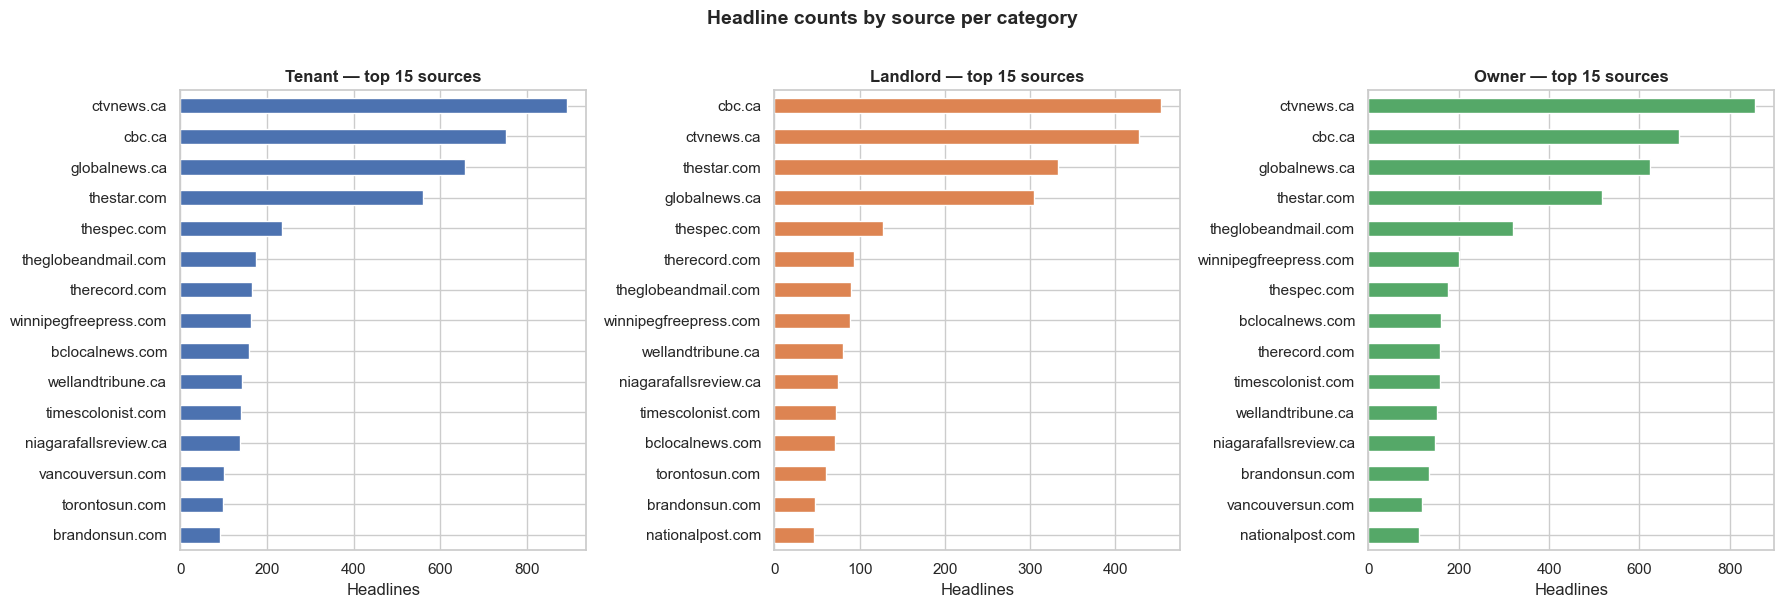

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for ax, (cat, colour) in zip(axes, CATEGORY_COLOURS.items()):
    sub = raw[raw["category"] == cat]
    top = sub["media_name"].value_counts().head(TOP_N_SOURCES)
    top.sort_values().plot(kind="barh", ax=ax, color=colour, edgecolor="white")
    ax.set_title(f"{cat.capitalize()} — top {TOP_N_SOURCES} sources", fontweight="bold")
    ax.set_xlabel("Headlines")
    ax.set_ylabel("")

plt.suptitle("Headline counts by source per category", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


In [6]:
# Share of top-5 outlets vs rest per category
for cat in CATEGORY_COLOURS:
    sub = raw[raw["category"] == cat]
    top5_share = sub["media_name"].value_counts().head(5).sum() / len(sub) * 100
    print(f"{cat:10s}  top-5 outlet share: {top5_share:.1f}%  (n={len(sub):,})")


tenant      top-5 outlet share: 54.5%  (n=5,683)
landlord    top-5 outlet share: 52.4%  (n=3,139)
owner       top-5 outlet share: 49.6%  (n=6,049)


---
## 3. Duplicate & Repeat Headlines
The same headline may appear in multiple outlet scrapes or be indexed multiple times. This section measures exact and near-exact repetition within each category file, and across categories (cross-posting).

**Key takeaway:** Headlines appearing verbatim many times are likely wire/syndicated stories; we flag them here but keep all rows for source-level analysis.


In [7]:
# Exact duplicate titles within each category
print("=== Exact duplicate titles (within category) ===\n")
for cat in CATEGORY_COLOURS:
    sub = raw[raw["category"] == cat]
    dup_counts = sub["title_lower"].value_counts()
    dup_gt1 = dup_counts[dup_counts > 1]
    print(f"[{cat}]  {len(dup_gt1)} unique titles appear more than once "
          f"({dup_gt1.sum() - len(dup_gt1)} extra rows / {len(sub):,} total)")
    print("  Top 5 most repeated:")
    for title, n in dup_gt1.head(5).items():
        print(f"    {n}×  {title[:90]}")
    print()


=== Exact duplicate titles (within category) ===

[tenant]  459 unique titles appear more than once (1095 extra rows / 5,683 total)
  Top 5 most repeated:
    12×  extreme heat deaths higher among seniors and in cities with more renters, study says
    11×  tenant group pushes for climate protections in report highlighting extreme heat risks
    11×  low-income renters press governments for ways to cool apartments in heat waves
    11×  b.c. short-term rental restrictions reducing rents, saving tenants millions: study
    11×  tenants offered accommodations and support after surprise mass eviction

[landlord]  283 unique titles appear more than once (709 extra rows / 3,139 total)
  Top 5 most repeated:
    12×  privacy commissioners investigate b.c. firm that does background checks for landlords
    12×  ndp asks competition watchdog to probe potential rent-fixing by corporate landlords
    10×  ontario landlords call for right to immediately ban pot in rentals despite tenant laws
    

In [8]:
# Cross-category: headlines appearing in more than one category file (same article id)
id_cats = raw.groupby("id")["category"].apply(set)
multi = id_cats[id_cats.map(len) > 1]
print(f"Article IDs appearing in >1 category: {len(multi):,} ({len(multi)/raw['id'].nunique()*100:.1f}% of unique IDs)\n")

pair_counter = Counter()
for cats in multi:
    cats_sorted = tuple(sorted(cats))
    pair_counter[cats_sorted] += 1

print("Cross-category pair counts:")
for pair, n in pair_counter.most_common():
    print(f"  {' + '.join(pair):35s}  {n:,}")


Article IDs appearing in >1 category: 1,215 (8.9% of unique IDs)

Cross-category pair counts:
  landlord + tenant                    1,093
  owner + tenant                       113
  landlord + owner                     6
  landlord + owner + tenant            3


---
## 4. Keyword Presence & Co-occurrence
Which specific keywords (tenant vs renter, landlord vs landlords, homeowner vs homebuyer, etc.) actually appear in the headlines, and how often do keywords from *different* categories appear in the same headline?


In [9]:
# Flag which keywords appear in each headline
all_kws = TENANT_KEYWORDS + LANDLORD_KEYWORDS + OWNER_KEYWORDS
for kw in all_kws:
    raw[f"kw_{kw.replace(' ', '_')}"] = raw["title_lower"].str.contains(
        rf"\b{re.escape(kw)}\b", regex=True)

# Keyword frequency by category (count of headlines containing each keyword)
print("=== Keyword frequency within each category file ===\n")
for cat in CATEGORY_COLOURS:
    sub = raw[raw["category"] == cat]
    kw_counts = {kw: sub[f"kw_{kw.replace(' ', '_')}"].sum() for kw in all_kws}
    kw_counts = {k: v for k, v in kw_counts.items() if v > 0}
    print(f"[{cat}]")
    for kw, n in sorted(kw_counts.items(), key=lambda x: -x[1]):
        print(f"  {kw:20s}  {n:,}  ({n/len(sub)*100:.1f}%)")
    print()


=== Keyword frequency within each category file ===

[tenant]
  tenants               2,879  (50.7%)
  tenant                1,300  (22.9%)
  renters               1,293  (22.8%)
  landlord              705  (12.4%)
  landlords             428  (7.5%)
  renter                185  (3.3%)
  tenancy               121  (2.1%)
  homeowners            73  (1.3%)
  homeowner             17  (0.3%)
  home buyers           12  (0.2%)
  homebuyers            9  (0.2%)
  home owners           4  (0.1%)
  homebuyer             1  (0.0%)

[landlord]
  landlord              1,671  (53.2%)
  landlords             1,472  (46.9%)
  tenants               535  (17.0%)
  tenant                456  (14.5%)
  renters               117  (3.7%)
  renter                20  (0.6%)
  tenancy               13  (0.4%)
  homeowners            5  (0.2%)
  homeowner             4  (0.1%)

[owner]
  homeowners            2,504  (41.4%)
  homeowner             1,525  (25.2%)
  homebuyers            928  (15.3%)
  home 

In [10]:
# Cross-category keyword co-occurrence in a single headline (using unique articles)
unique_articles = raw.drop_duplicates(subset="id").copy()

def has_cat_kw(row, cat):
    return any(row[f"kw_{kw.replace(' ', '_')}"] for kw in CATEGORY_KEYWORDS[cat])

for cat in CATEGORY_COLOURS:
    unique_articles[f"has_{cat}"] = unique_articles.apply(has_cat_kw, axis=1, args=(cat,))

cats = list(CATEGORY_COLOURS.keys())
print("=== Cross-category co-occurrence (unique article IDs) ===\n")
for i, c1 in enumerate(cats):
    for c2 in cats[i+1:]:
        both = (unique_articles[f"has_{c1}"] & unique_articles[f"has_{c2}"]).sum()
        total = len(unique_articles)
        print(f"  {c1} + {c2}: {both:,} headlines ({both/total*100:.1f}% of {total:,} unique articles)")

all_three = (unique_articles["has_tenant"] & unique_articles["has_landlord"] & unique_articles["has_owner"]).sum()
print(f"  all three: {all_three:,} headlines")


=== Cross-category co-occurrence (unique article IDs) ===

  tenant + landlord: 1,146 headlines (8.4% of 13,653 unique articles)
  tenant + owner: 116 headlines (0.8% of 13,653 unique articles)
  landlord + owner: 9 headlines (0.1% of 13,653 unique articles)
  all three: 3 headlines


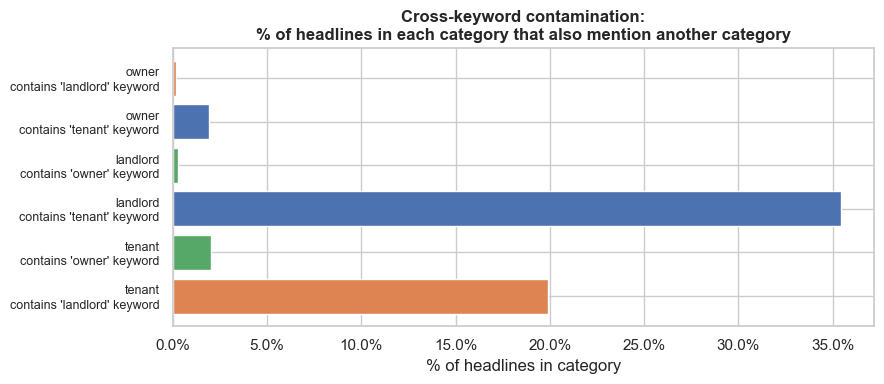

In [11]:
# Venn-style bar: how many headlines in each category ALSO contain another category's keywords
fig, ax = plt.subplots(figsize=(9, 4))

labels, values, colours = [], [], []
for cat in cats:
    sub = raw[raw["category"] == cat].drop_duplicates("id")
    other_cats = [c for c in cats if c != cat]
    for ocat in other_cats:
        both = sub.apply(has_cat_kw, axis=1, args=(ocat,)).sum()
        labels.append(f"{cat}\ncontains '{ocat}' keyword")
        values.append(both / len(sub) * 100)
        colours.append(CATEGORY_COLOURS[ocat])

y_pos = range(len(labels))
bars = ax.barh(list(y_pos), values, color=colours, edgecolor="white")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel("% of headlines in category")
ax.set_title("Cross-keyword contamination:\n% of headlines in each category that also mention another category", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.show()


---
## 5. Longitudinal Trends
How has coverage volume for each category changed over time? We look at monthly headline counts per category and whether the three groups are trending similarly or diverging.


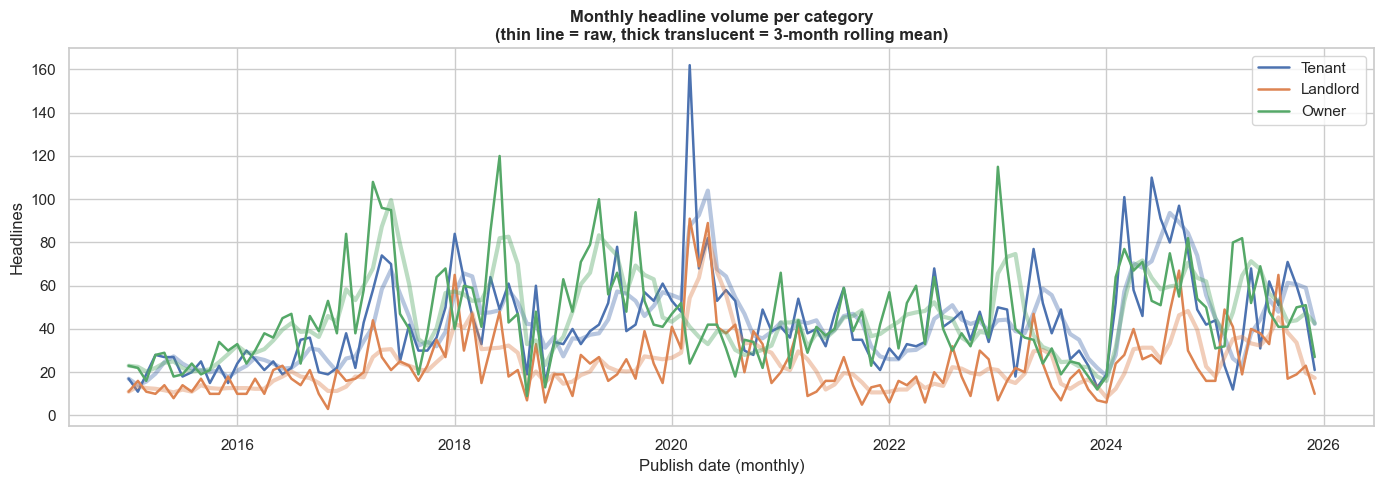

In [12]:
monthly = (
    raw.dropna(subset=["publish_date"])
    .assign(month=lambda d: d["publish_date"].dt.to_period("M"))
    .groupby(["month", "category"])
    .size()
    .reset_index(name="n")
)
monthly["month_dt"] = monthly["month"].dt.to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
for cat, colour in CATEGORY_COLOURS.items():
    sub = monthly[monthly["category"] == cat].sort_values("month_dt")
    ax.plot(sub["month_dt"], sub["n"], label=cat.capitalize(), color=colour, linewidth=1.8)
    # 3-month rolling mean
    ax.plot(sub["month_dt"], sub["n"].rolling(3, min_periods=1).mean(),
            color=colour, linewidth=3, alpha=0.4)

ax.set_xlabel("Publish date (monthly)")
ax.set_ylabel("Headlines")
ax.set_title("Monthly headline volume per category\n(thin line = raw, thick translucent = 3-month rolling mean)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
# Yearly totals for a cleaner summary
yearly = (
    raw.dropna(subset=["publish_date"])
    .assign(year=lambda d: d["publish_date"].dt.year)
    .groupby(["year", "category"])
    .size()
    .reset_index(name="n")
)

pivot = yearly.pivot(index="year", columns="category", values="n").fillna(0).astype(int)
print("Yearly headline counts per category:\n")
print(pivot.to_string())


Yearly headline counts per category:

category  landlord  owner  tenant
year                             
2015           150    283     245
2016           177    453     299
2017           294    755     518
2018           340    598     575
2019           263    761     569
2020           549    421     723
2021           214    490     464
2022           210    519     474
2023           213    448     472
2024           359    717     821
2025           370    604     523


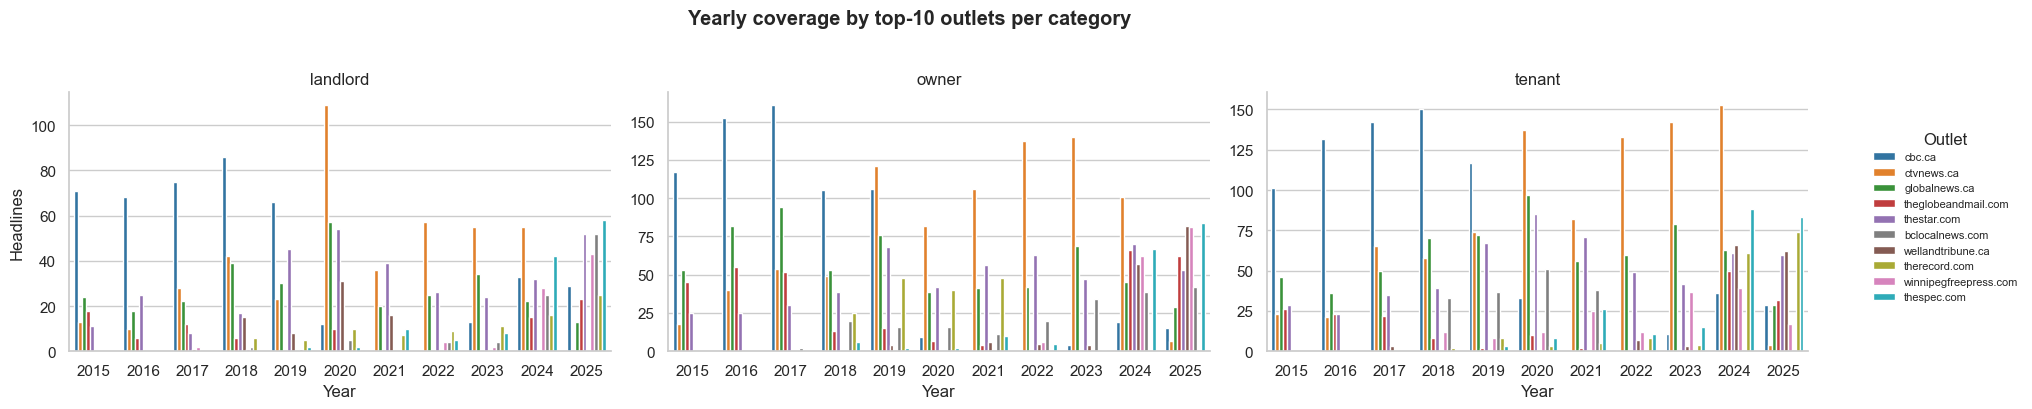

In [14]:
# Coverage by source AND year — which outlets dominate in which years?
major_sources = raw["media_name"].value_counts().head(10).index.tolist()

src_year = (
    raw[raw["media_name"].isin(major_sources)]
    .assign(year=lambda d: d["publish_date"].dt.year)
    .groupby(["year", "media_name", "category"])
    .size()
    .reset_index(name="n")
)

g = sns.FacetGrid(src_year, col="category", sharey=False, height=4, aspect=1.4)
g.map_dataframe(
    sns.barplot, x="year", y="n", hue="media_name",
    palette="tab10", dodge=True, errorbar=None
)
g.add_legend(title="Outlet", bbox_to_anchor=(1.02, 0.5), loc="center left", fontsize=8)
g.set_axis_labels("Year", "Headlines")
g.set_titles("{col_name}")
g.figure.suptitle("Yearly coverage by top-10 outlets per category", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## 6. Topic Taxonomy: What Are Headlines Actually About?

Ten mutually-exclusive (first-match) themes cover the substantive content of housing headlines. The distribution across entity categories reveals which aspects of housing each corpus foregrounds.


In [15]:

# --- 10-theme taxonomy (first-match, keyword-based) ---
THEMES = {
    "Policy / Regulation": [
        "bill", "law", "legislation", "bylaw", "policy", "regulation", "rent control",
        "rent freeze", "rent cap", "rent board", "tribunal", "ltb", "landlord tenant board",
        "act ", "zoning", "municipal", "provincial", "federal", "government",
    ],
    "Evictions / Enforcement": [
        "evict", "eviction", "notice to vacate", "notice to leave", "n12", "n13",
        "own use", "demovict", "demoviction", "illegal evict", "wrongful evict",
        "bailiff", "sheriff", "enforcement", "order to vacate",
    ],
    "Rent Prices / Affordability": [
        "afford", "rent hike", "rent increase", "rent spike", "rent surge",
        "rent rise", "rent raise", "high rent", "rent price", "rent cost",
        "rent burden", "rent relief", "rent subsid", "rent assist",
        "rental rate", "average rent", "median rent",
    ],
    "Landlord Business / Conditions": [
        "landlord", "property owner", "property manager", "property management",
        "small landlord", "mom and pop", "rental income", "rental revenue",
        "mortgage cost", "operating cost", "property tax", "vacant unit",
        "cash flow", "landlord association",
    ],
    "Homeownership / Household Finance": [
        "homeowner", "home owner", "home buyer", "home purchase", "mortgage",
        "interest rate", "down payment", "first-time buyer", "housing market",
        "home price", "housing price", "real estate agent", "bidding war",
    ],
    "Supply / Development / Market": [
        "build", "construction", "development", "developer", "new unit",
        "purpose-built", "rental supply", "vacancy rate", "housing start",
        "housing supply", "zoning reform", "upzoning", "intensif",
        "planning", "permit", "condo", "multiplex", "missing middle",
    ],
    "Profit / Investment / Financialization": [
        "invest", "reit", "real estate investment", "corporate landlord",
        "financializ", "commodif", "profit", "specul", "flip",
        "airbnb", "short-term rental", "foreign buyer", "offshore buyer",
        "asset", "portfolio", "acquisition",
    ],
    "Advocacy / Rights / Organizing": [
        "tenant union", "rent strike", "protest", "activist", "advocate",
        "organiz", "tenant right", "human right", "housing right",
        "petition", "campaign", "rally", "fight back", "tenant group",
        "legal aid", "community group",
    ],
    "Housing Conditions / Safety / Risk": [
        "repair", "maintenance", "mold", "mould", "bed bug", "pest",
        "unsafe", "hazard", "fire", "flood", "unsafe condition",
        "disrepair", "water damage", "heating", "no heat", "black mold",
        "cockroach", "slumlord",
    ],
    "Homelessness / Displacement / Precarity": [
        "homeless", "homelessness", "shelter", "encampment",
        "displace", "displacement", "forced out", "nowhere to go",
        "housing insecure", "couch surf", "precari",
        "under housed", "unhoused", "living in car",
    ],
}

def classify_theme(title: str) -> str:
    t = title.lower()
    for theme, kws in THEMES.items():
        for kw in kws:
            if kw in t:
                return theme
    return "Other / General"

raw["theme"] = raw["title"].apply(classify_theme)

theme_order = list(THEMES.keys()) + ["Other / General"]
theme_counts = (
    raw.groupby(["category", "theme"])
    .size()
    .reset_index(name="n")
)
# convert to % within category
totals = raw.groupby("category").size().rename("total")
theme_counts = theme_counts.join(totals, on="category")
theme_counts["pct"] = theme_counts["n"] / theme_counts["total"] * 100

print(theme_counts.pivot(index="theme", columns="category", values="pct")
      .reindex(theme_order).round(1).to_string())


category                                 landlord  owner  tenant
theme                                                           
Policy / Regulation                          11.9    7.8    11.5
Evictions / Enforcement                       8.6    0.3     9.6
Rent Prices / Affordability                   3.0    1.0     4.9
Landlord Business / Conditions               76.5    2.0    14.4
Homeownership / Household Finance             NaN   76.5     2.8
Supply / Development / Market                 NaN    0.6     8.1
Profit / Investment / Financialization        NaN    0.3     1.9
Advocacy / Rights / Organizing                NaN    0.1     2.8
Housing Conditions / Safety / Risk            NaN    0.1     6.8
Homelessness / Displacement / Precarity       NaN    0.0     1.8
Other / General                               NaN   11.3    35.5


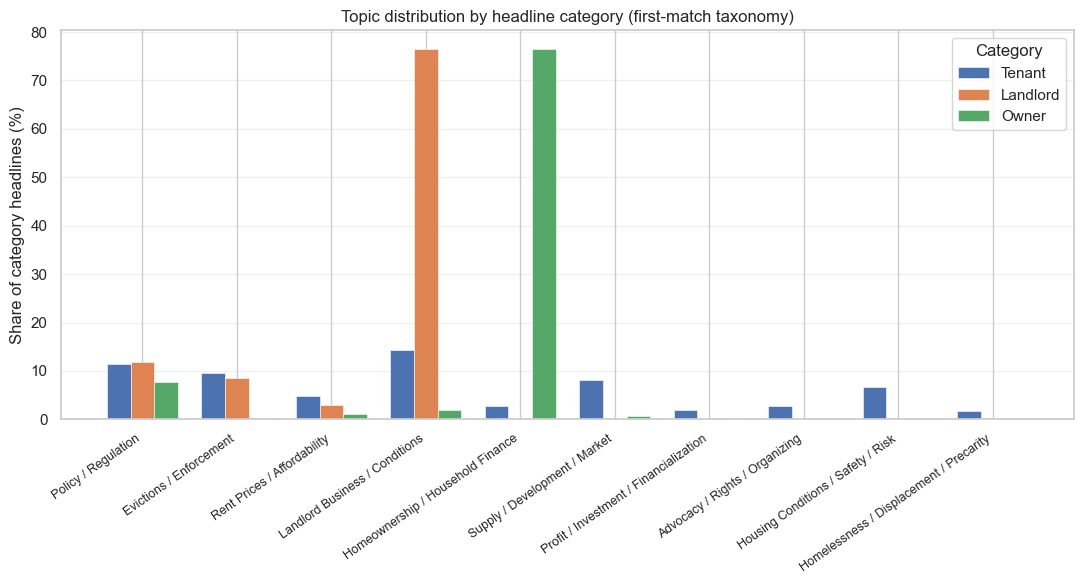

In [16]:

# Chart: theme distribution by category (excluding "Other / General")
plot_themes = [t for t in theme_order if t != "Other / General"]
pivot_themes = (
    theme_counts[theme_counts["theme"].isin(plot_themes)]
    .pivot(index="theme", columns="category", values="pct")
    .reindex(plot_themes)
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(plot_themes))
w = 0.25
cats_plot = ["tenant", "landlord", "owner"]
colours_plot = [CATEGORY_COLOURS[c] for c in cats_plot]

for i, (cat, col) in enumerate(zip(cats_plot, colours_plot)):
    bars = ax.bar(x + (i - 1) * w, pivot_themes[cat], width=w, color=col,
                  label=cat.capitalize(), edgecolor="white", linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(plot_themes, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Share of category headlines (%)")
ax.set_title("Topic distribution by headline category (first-match taxonomy)", fontsize=12)
ax.legend(title="Category")
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 7. Grammatical Agency: Who Acts, Who Is Acted Upon?

Using spaCy dependency parsing, each headline is classified by whether the target entity appears as an **active grammatical subject** (agent), a **passive/object** (acted-upon), or neither. A high "acted-upon" ratio signals that media portrays an entity as a recipient of others' actions rather than an initiator.


In [17]:

# --- 7a: Grammatical role distribution ---
role_counts = (
    raw.groupby(["category", "dep_role"])
    .size()
    .reset_index(name="n")
)
role_totals = raw.groupby("category").size().rename("total")
role_counts = role_counts.join(role_totals, on="category")
role_counts["pct"] = role_counts["n"] / role_counts["total"] * 100

role_pivot = role_counts.pivot(index="dep_role", columns="category", values="pct").fillna(0)
print("Grammatical role (% of headlines per category):")
print(role_pivot.round(1).to_string())
print()

# Acted-upon ratio
PASSIVE_ROLES = ["passive subject", "direct object", "prep. object"]
for cat in ["tenant", "landlord", "owner"]:
    sub = role_pivot[cat]
    passive_sum = sum(sub.get(r, 0) for r in PASSIVE_ROLES)
    active = sub.get("active subject", 0.01)
    ratio = passive_sum / max(active, 0.01)
    print(f"  {cat}: acted-upon ratio = {ratio:.2f}x  (passive+obj {passive_sum:.1f}% vs active {active:.1f}%)")


KeyError: 'dep_role'

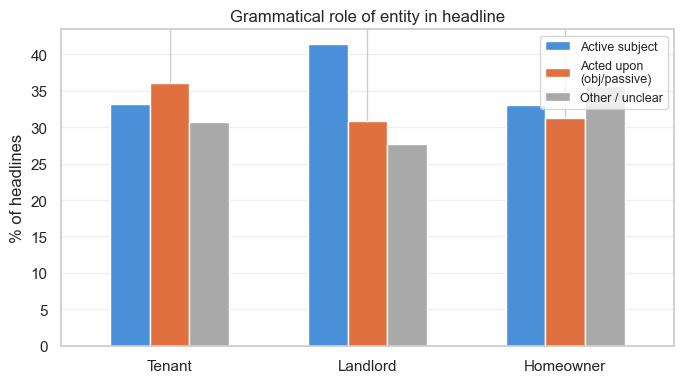

In [ ]:

# Chart: active subject vs. acted-upon (direct + passive + prep) vs. other
def make_role_summary(cat):
    sub = role_pivot[cat]
    return {
        "Active subject": sub.get("active subject", 0),
        "Acted upon\n(obj/passive)": sub.get("direct object", 0)
                                     + sub.get("passive subject", 0)
                                     + sub.get("prep. object", 0),
        "Other / unclear": sub.get("other", 0) + sub.get("not_found", 0),
    }

role_summary = {cat: make_role_summary(cat) for cat in ["tenant", "landlord", "owner"]}
rs_df = pd.DataFrame(role_summary).T

fig, ax = plt.subplots(figsize=(7, 4))
rs_df.plot(kind="bar", ax=ax, color=["#4A90D9", "#E07040", "#A9A9A9"],
           edgecolor="white", width=0.6)
ax.set_xticklabels(["Tenant", "Landlord", "Homeowner"], rotation=0)
ax.set_ylabel("% of headlines")
ax.set_title("Grammatical role of entity in headline", fontsize=12)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()


## 8. Media Bias Analysis: Who Gets Sympathy, Who Gets Blame?

This section applies four directional framing lexicons:

| Lexicon | What it detects |
|---|---|
| **Tenant-blaming** | Headlines that cast tenants as bad actors: refusing to pay, squatting, "professional tenant" |
| **Tenant-sympathetic** | Headlines framing tenants as victims: evicted, displaced, unaffordable, struggling |
| **Landlord-sympathetic** | Headlines framing landlords as victims: can't afford, losing money, struggling small landlord |
| **Landlord-critical** | Headlines framing landlords as wrongdoers: sued, fined, illegal, greedy, exploiting |

A **pro-landlord bias ratio** compares landlord sympathy to landlord criticism, and tenant blame to tenant sympathy.


In [ ]:

# --- 8a: Define directional framing lexicons ---

TENANT_BLAME = [
    "professional tenant", "refusing to pay", "refuse to pay", "refusing to leave",
    "refuse to leave", "won't leave", "won't pay", "wont leave", "wont pay",
    "non-payment", "non payment", "unpaid rent", "rent arrears",
    "squatter", "squatters", "squatting", "deadbeat", "problem tenant",
    "bad tenant", "tenant from hell", "damage", "vandal", "illegal occupant",
    "overstaying", "trespassing",
]
TENANT_SYMPATHY = [
    "evicted", "eviction", "face eviction", "facing eviction", "illegally evicted",
    "wrongful eviction", "displace", "displacement", "displaced",
    "can't afford", "cannot afford", "struggling to pay", "unaffordable",
    "rent burden", "housing insecure", "nowhere to go", "forced out",
    "housing crisis", "rent hike", "rent spike", "rent surge",
    "renovict", "demovict", "own-use eviction", "above guideline",
]
LANDLORD_SYMPATHY = [
    "small landlord", "mom and pop", "mom-and-pop", "can't afford", "cannot afford",
    "losing money", "struggling landlord", "losing rental", "mortgage cost",
    "property tax burden", "cash flow problem", "rental income loss",
    "won't pay rent", "tenant damage", "unpaid rent", "rent arrears",
    "landlord victim", "left holding", "landlord struggle",
    "hard to evict", "difficult to evict", "landlord nightmare",
]
LANDLORD_CRITICAL = [
    "sued", "fined", "charged", "convicted", "ordered to pay", "ordered to repay",
    "illegal eviction", "illegally evicted", "wrongful eviction",
    "slumlord", "greedy landlord", "exploiting", "gouging",
    "renoviction", "demoviction", "above guideline increase",
    "human rights", "tribunal order", "contempt of court",
    "unsafe condition", "mold", "mould", "no heat", "pest infestation",
    "violated", "violation", "breach",
]

def flag_any(title: str, keywords: list) -> bool:
    t = title.lower()
    return any(kw in t for kw in keywords)

uniq = raw.drop_duplicates(subset="id")[["id", "title", "category", "publish_date", "media_name"]].copy()

uniq["tenant_blame"]      = uniq["title"].apply(lambda t: flag_any(t, TENANT_BLAME))
uniq["tenant_sympathy"]   = uniq["title"].apply(lambda t: flag_any(t, TENANT_SYMPATHY))
uniq["landlord_sympathy"] = uniq["title"].apply(lambda t: flag_any(t, LANDLORD_SYMPATHY))
uniq["landlord_critical"] = uniq["title"].apply(lambda t: flag_any(t, LANDLORD_CRITICAL))

# Summary counts across ALL headlines (not per category — these cut across categories)
labels_8 = {
    "tenant_blame":      "Tenant-blaming",
    "tenant_sympathy":   "Tenant-sympathetic",
    "landlord_sympathy": "Landlord-sympathetic",
    "landlord_critical": "Landlord-critical",
}
total_uniq = len(uniq)
for col, label in labels_8.items():
    n = uniq[col].sum()
    print(f"  {label:30s}: {n:4d}  ({n/total_uniq*100:.1f}% of unique articles)")

print()
tb = uniq["tenant_blame"].sum()
ts = uniq["tenant_sympathy"].sum()
ls = uniq["landlord_sympathy"].sum()
lc = uniq["landlord_critical"].sum()
print(f"  Tenant  blame:sympathy ratio    = {tb}/{ts} = {tb/max(ts,1):.3f}")
print(f"  Landlord sympathy:critical ratio = {ls}/{lc} = {ls/max(lc,1):.3f}")


  Tenant-blaming                :  259  (1.9% of unique articles)
  Tenant-sympathetic            : 1113  (8.2% of unique articles)
  Landlord-sympathetic          :   58  (0.4% of unique articles)
  Landlord-critical             :  619  (4.5% of unique articles)

  Tenant  blame:sympathy ratio    = 259/1113 = 0.233
  Landlord sympathy:critical ratio = 58/619 = 0.094


Framing direction (% of each category's headlines):
category              tenant  landlord  owner
framing                                      
Landlord-critical       5.37      7.05   2.87
Landlord-sympathetic    0.35      1.52   0.12
Tenant-blaming          2.23      2.99   1.20
Tenant-sympathetic     16.51      7.24   0.46


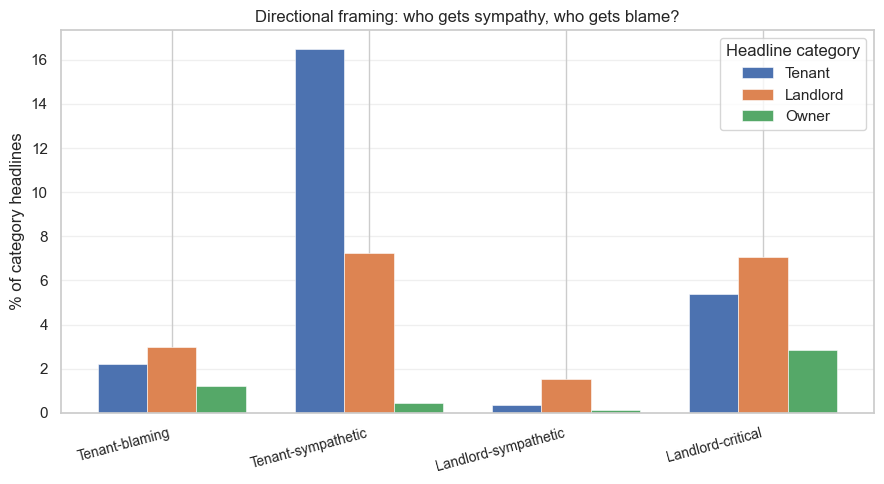

In [ ]:

# --- 8b: Framing direction breakdown per source category ---
# For each category, what share of headlines carry each framing?
bias_rows = []
for cat in ["tenant", "landlord", "owner"]:
    sub = uniq[uniq["category"] == cat]
    n_cat = len(sub)
    for col, label in labels_8.items():
        n = sub[col].sum()
        bias_rows.append({
            "category": cat,
            "framing": label,
            "n": n,
            "pct": n / n_cat * 100,
        })

bias_df = pd.DataFrame(bias_rows)
bias_pivot = bias_df.pivot(index="framing", columns="category", values="pct")
print("Framing direction (% of each category's headlines):")
print(bias_pivot[["tenant", "landlord", "owner"]].round(2).to_string())

# Chart
fig, ax = plt.subplots(figsize=(9, 5))
framing_order = ["Tenant-blaming", "Tenant-sympathetic", "Landlord-sympathetic", "Landlord-critical"]
bp = bias_pivot.reindex(framing_order)
x = np.arange(len(framing_order))
w = 0.25
for i, (cat, col) in enumerate(zip(["tenant", "landlord", "owner"],
                                    [CATEGORY_COLOURS[c] for c in ["tenant", "landlord", "owner"]])):
    ax.bar(x + (i - 1) * w, bp[cat], width=w, color=col,
           label=cat.capitalize(), edgecolor="white", linewidth=0.4)

ax.set_xticks(x)
ax.set_xticklabels(framing_order, rotation=15, ha="right", fontsize=10)
ax.set_ylabel("% of category headlines")
ax.set_title("Directional framing: who gets sympathy, who gets blame?", fontsize=12)
ax.legend(title="Headline category")
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


In [ ]:

# --- 8c: Tenant-blaming examples —– "professional tenant" and kin ---
tb_examples = (
    uniq[uniq["tenant_blame"]]
    .sort_values("publish_date")
    [["publish_date", "category", "media_name", "title"]]
    .head(40)
)

print(f"=== Tenant-blaming headlines (n={uniq['tenant_blame'].sum()}) ===\n")
for _, row in tb_examples.iterrows():
    date = str(row["publish_date"])[:10]
    print(f"[{date}] [{row['category']:8s}] {row['media_name']}")
    print(f"  {row['title']}\n")


=== Tenant-blaming headlines (n=259) ===

[2015-01-10] [tenant  ] globalnews.ca
  “Everything is gone”: Tenants come to grips with damages from apartment fire

[2015-01-10] [owner   ] cbc.ca
  Flooded homeowners blame ministry 'repairs' for more than $250K in damage

[2015-02-02] [owner   ] cbc.ca
  Hundreds of Stoney Nakoda homeowners still waiting for flood damage repairs

[2015-02-06] [tenant  ] cbc.ca
  Penny Drive residents want problem tenants evicted

[2015-05-04] [tenant  ] globalnews.ca
  Damages could hit $150,000 in Calgary home trashed by Airbnb renters

[2015-05-04] [tenant  ] globalnews.ca
  Damages could hit $150,000 in Calgary home trashed by Airbnb renters

[2015-05-26] [tenant  ] cbc.ca
  Bad tenant - CBC News

[2015-06-11] [tenant  ] globalnews.ca
  Fire damages home in Calgary’s Arbour Lake; basement tenant now accounted for

[2015-06-15] [owner   ] cbc.ca
  Quebec City homeowners suing over damage caused by soggy soil

[2015-07-24] [owner   ] thestar.com
  Seller, 

In [ ]:

# --- 8d: Landlord-sympathetic examples ---
ls_examples = (
    uniq[uniq["landlord_sympathy"]]
    .sort_values("publish_date")
    [["publish_date", "category", "media_name", "title"]]
    .head(30)
)

print(f"=== Landlord-sympathetic headlines (n={uniq['landlord_sympathy'].sum()}) ===\n")
for _, row in ls_examples.iterrows():
    date = str(row["publish_date"])[:10]
    print(f"[{date}] [{row['category']:8s}] {row['media_name']}")
    print(f"  {row['title']}\n")


=== Landlord-sympathetic headlines (n=58) ===

[2016-05-04] [landlord] ottawacitizen.com
  Landlord evicts Ottawa Neighbourhood Services after unpaid rent

[2016-05-17] [owner   ] torontosun.com
  This northern flicker won't leave a Calgary attic, won't pay rent, and the homeowner is completely powerless

[2016-09-24] [tenant  ] cbc.ca
  Bad tenants are too hard to evict and it takes too long, expert says

[2017-02-23] [tenant  ] brantfordexpositor.ca
  New York landlord 'went nuts,' allegedly stabbed tenant to death over unpaid rent

[2017-02-23] [tenant  ] torontosun.com
  New York landlord 'went nuts,' allegedly stabbed tenant to death over unpaid rent

[2017-02-23] [tenant  ] canoe.com
  New York landlord 'went nuts,' allegedly stabbed tenant to death over unpaid rent

[2017-02-23] [tenant  ] ctvnews.ca
  Landlord accused of killing tenant over unpaid rent

[2017-11-29] [tenant  ] cbc.ca
  Fully employed young professionals can't afford rent: The plight of big city renters

[2018-1

In [ ]:

# --- 8e: "Professional tenant" and related anti-tenant framing ---
anti_tenant_phrases = [
    "professional tenant", "bad tenant", "problem tenant", "tenant from hell",
    "hard to evict", "difficult to evict", "refuse to leave", "refusing to leave",
    "won't leave", "squatter", "deadbeat",
]
print("=== Anti-tenant framing by phrase ===\n")
for phrase in anti_tenant_phrases:
    hits = uniq[uniq["title"].str.lower().str.contains(phrase, na=False)]
    if len(hits) > 0:
        print(f"  '{phrase}' — {len(hits)} headlines:")
        for _, r in hits.head(5).iterrows():
            date = str(r["publish_date"])[:10]
            print(f"    [{date}] [{r['category']:8s}] {r['media_name']}: {r['title']}")
        print()


=== Anti-tenant framing by phrase ===

  'professional tenant' — 10 headlines:
    [2016-09-23] [tenant  ] cbc.ca: Yorkville landlord can't evict well-dressed "professional tenant" who isn't paying rent
    [2016-09-23] [tenant  ] cbc.ca: Yorkville landlord can't evict well-dressed "professional tenant" who isn't paying rent
    [2016-10-04] [tenant  ] cbc.ca: Fraud is difficult to prove, police say, as more allegations surface against 'professional tenant'
    [2016-11-22] [tenant  ] cbc.ca: 'Professional tenant' James Regan surrenders to Toronto police
    [2016-11-22] [tenant  ] cbc.ca: 'Professional tenant' James Regan wanted for allegedly assaulting ex-landlord

  'bad tenant' — 12 headlines:
    [2015-05-26] [tenant  ] cbc.ca: Bad tenant - CBC News
    [2015-12-19] [tenant  ] thestar.com: Bad tenant pleads guilty to charges
    [2016-09-24] [tenant  ] cbc.ca: Bad tenants are too hard to evict and it takes too long, expert says
    [2016-06-02] [tenant  ] ottawacitizen.com: Compan

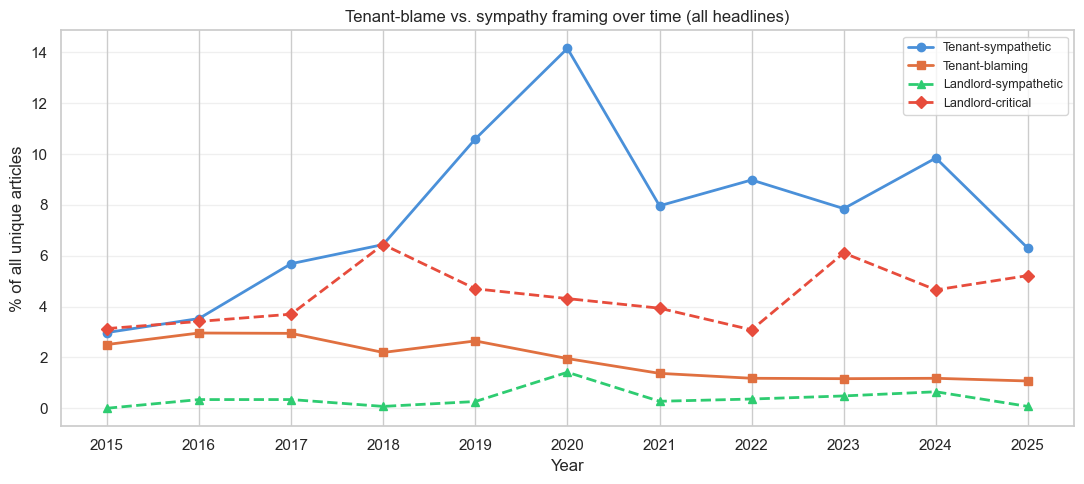

 year  total  tenant_blame_pct  tenant_sympathy_pct  landlord_sympathy_pct  landlord_critical_pct
 2015    638          2.507837             2.978056               0.000000               3.134796
 2016    878          2.961276             3.530752               0.341686               3.416856
 2017   1459          2.947224             5.688828               0.342700               3.701165
 2018   1366          2.196193             6.442167               0.073206               6.442167
 2019   1510          2.649007            10.596026               0.264901               4.701987
 2020   1483          1.955496            14.160486               1.416049               4.315577
 2021   1092          1.373626             7.967033               0.274725               3.937729
 2022   1102          1.179673             8.983666               0.362976               3.085299
 2023   1031          1.163919             7.856450               0.484966               6.110572
 2024   1696        

In [ ]:

# --- 8f: Temporal trend — tenant-blame vs tenant-sympathy vs landlord-sympathy ---
uniq["year"] = pd.to_datetime(uniq["publish_date"], errors="coerce").dt.year
yearly_bias = (
    uniq.groupby("year")[["tenant_blame", "tenant_sympathy", "landlord_sympathy", "landlord_critical"]]
    .sum()
    .reset_index()
)
yearly_totals = uniq.groupby("year").size().rename("total").reset_index()
yearly_bias = yearly_bias.merge(yearly_totals, on="year")
for col in ["tenant_blame", "tenant_sympathy", "landlord_sympathy", "landlord_critical"]:
    yearly_bias[col + "_pct"] = yearly_bias[col] / yearly_bias["total"] * 100

yearly_bias = yearly_bias[yearly_bias["year"].between(2015, 2025)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly_bias["year"], yearly_bias["tenant_sympathy_pct"],
        marker="o", label="Tenant-sympathetic", color="#4A90D9", linewidth=2)
ax.plot(yearly_bias["year"], yearly_bias["tenant_blame_pct"],
        marker="s", label="Tenant-blaming", color="#E07040", linewidth=2)
ax.plot(yearly_bias["year"], yearly_bias["landlord_sympathy_pct"],
        marker="^", label="Landlord-sympathetic", color="#2ECC71", linewidth=2, linestyle="--")
ax.plot(yearly_bias["year"], yearly_bias["landlord_critical_pct"],
        marker="D", label="Landlord-critical", color="#E74C3C", linewidth=2, linestyle="--")

ax.set_xlabel("Year")
ax.set_ylabel("% of all unique articles")
ax.set_title("Tenant-blame vs. sympathy framing over time (all headlines)", fontsize=12)
ax.legend(fontsize=9)
ax.yaxis.grid(True, alpha=0.3)
ax.set_axisbelow(True)
ax.set_xticks(range(2015, 2026))
plt.tight_layout()
plt.show()

print(yearly_bias[["year", "total", "tenant_blame_pct", "tenant_sympathy_pct",
                    "landlord_sympathy_pct", "landlord_critical_pct"]].to_string(index=False))


## 9. Summary: Key Findings on Housing Media Coverage

Consolidated findings across all analytical dimensions.


In [ ]:

# --- 9: Summary table ---
summary_rows = []

# Volume
for cat in ["tenant", "landlord", "owner"]:
    n = (raw["category"] == cat).sum()
    n_uniq = (uniq["category"] == cat).sum()
    summary_rows.append({"dimension": "Article count (raw)", "metric": cat.capitalize(), "value": f"{n:,}"})
    summary_rows.append({"dimension": "Article count (unique IDs)", "metric": cat.capitalize(), "value": f"{n_uniq:,}"})

# Top source share
for cat in ["tenant", "landlord", "owner"]:
    sub = raw[raw["category"] == cat]
    top5 = sub["media_name"].value_counts().head(5).sum() / len(sub) * 100
    summary_rows.append({"dimension": "Top-5 outlet share", "metric": cat.capitalize(), "value": f"{top5:.0f}%"})

# Theme concentration (most common theme)
for cat in ["tenant", "landlord", "owner"]:
    sub = raw[raw["category"] == cat]
    top_theme = sub["theme"].value_counts().idxmax()
    top_pct = sub["theme"].value_counts().max() / len(sub) * 100
    summary_rows.append({"dimension": "Dominant theme", "metric": cat.capitalize(),
                          "value": f"{top_theme} ({top_pct:.0f}%)"})

# Grammatical agency (acted-upon ratio)
PASSIVE_ROLES2 = ["passive subject", "direct object", "prep. object"]
for cat in ["tenant", "landlord", "owner"]:
    sub_rp = role_pivot[cat]
    passive_sum = sum(sub_rp.get(r, 0) for r in PASSIVE_ROLES2)
    active = sub_rp.get("active subject", 0.01)
    ratio = passive_sum / max(active, 0.01)
    summary_rows.append({"dimension": "Grammatical acted-upon ratio", "metric": cat.capitalize(),
                          "value": f"{ratio:.2f}x"})

# Framing direction (all unique headlines)
total_u = len(uniq)
for col, label in labels_8.items():
    n = uniq[col].sum()
    summary_rows.append({"dimension": "Framing (all unique)", "metric": label,
                          "value": f"{n} ({n/total_u*100:.1f}%)"})

# Bias ratios
summary_rows.append({"dimension": "Bias ratio", "metric": "Tenant blame:sympathy",
                      "value": f"{tb}/{ts} = {tb/max(ts,1):.2f}"})
summary_rows.append({"dimension": "Bias ratio", "metric": "Landlord sympathy:critical",
                      "value": f"{ls}/{lc} = {ls/max(lc,1):.2f}"})

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))


                   dimension                     metric                                   value
         Article count (raw)                     Tenant                                   5,683
  Article count (unique IDs)                     Tenant                                   5,683
         Article count (raw)                   Landlord                                   3,139
  Article count (unique IDs)                   Landlord                                   2,043
         Article count (raw)                      Owner                                   6,049
  Article count (unique IDs)                      Owner                                   5,927
          Top-5 outlet share                     Tenant                                     55%
          Top-5 outlet share                   Landlord                                     52%
          Top-5 outlet share                      Owner                                     50%
              Dominant theme            